In [1]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.quantization
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [2]:
from google.colab import files
files.upload()

Saving kaggle3.json to kaggle3.json


{'kaggle3.json': b'{"username":"rambhadrakumar","key":"32c81b7b282d0e78edb892f9a59b7c1b"}'}

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d mahmoudreda55/satellite-image-classification --unzip -p /content/satellite')
print("Download complete!")
print(sorted(os.listdir('/content/satellite/data')))

Download complete!
['cloudy', 'desert', 'green_area', 'water']


In [4]:
DATA_DIR    = '/content/satellite/data'
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 15
EPOCHS_P2   = 15
NUM_CLASSES = len(os.listdir(DATA_DIR))
print("Number of classes:", NUM_CLASSES)
print("Classes:", sorted(os.listdir(DATA_DIR)))

Number of classes: 4
Classes: ['cloudy', 'desert', 'green_area', 'water']


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
class_names  = full_dataset.classes
print("Classes:", class_names)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")

Classes: ['cloudy', 'desert', 'green_area', 'water']
Train samples: 4504
Val samples  : 1127


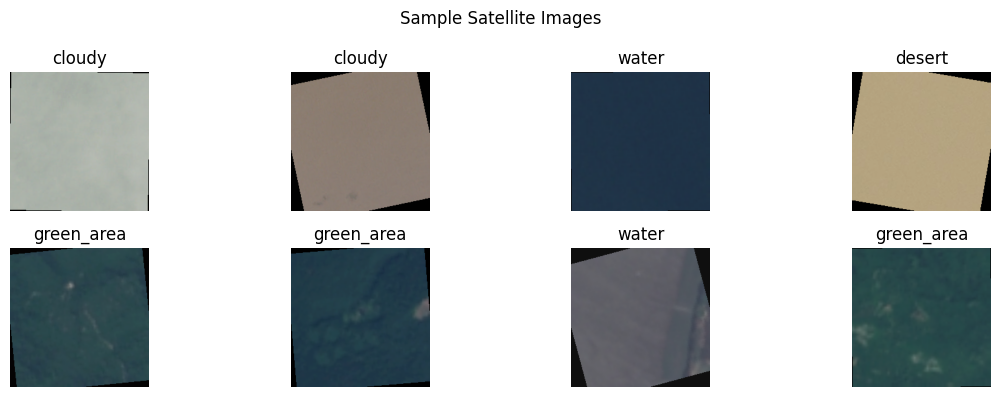

In [6]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(min(8, len(images))):
    img = images[i].permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)
    plt.subplot(2, 4, i+1)
    plt.imshow(img.numpy())
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.suptitle('Sample Satellite Images')
plt.tight_layout()
plt.show()

In [7]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[6].in_features

model.classifier[6] = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)
print("Model ready!")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 73.5MB/s]


Model ready!
Trainable params: 2,231,556


In [8]:
def train_model(mdl, train_ldr, val_ldr, optimizer, scheduler, criterion, epochs, phase_name):
    train_acc_list = []
    val_acc_list   = []
    best_acc       = 0.0
    best_weights   = copy.deepcopy(mdl.state_dict())

    for epoch in range(epochs):
        mdl.train()
        correct, total, running_loss = 0, 0, 0.0

        for images, labels in train_ldr:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = mdl(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_acc = correct / total

        mdl.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_ldr:
                images, labels = images.to(device), labels.to(device)
                outputs = mdl(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = copy.deepcopy(mdl.state_dict())

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"[{phase_name}] Epoch {epoch+1}/{epochs}  "
              f"Loss: {running_loss/len(train_ldr):.4f}  "
              f"Train: {train_acc*100:.2f}%  "
              f"Val: {val_acc*100:.2f}%")

    mdl.load_state_dict(best_weights)
    print(f"\nBest Val Accuracy: {best_acc*100:.2f}%")
    return train_acc_list, val_acc_list

In [9]:
criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer1, mode='max', factor=0.5, patience=2)

print("=== PHASE 1: Training classifier head ===")
train_acc1, val_acc1 = train_model(
    model, train_loader, val_loader,
    optimizer1, scheduler1, criterion,
    epochs=EPOCHS_P1,
    phase_name='Phase 1'
)

=== PHASE 1: Training classifier head ===
[Phase 1] Epoch 1/15  Loss: 0.4252  Train: 84.30%  Val: 97.60%
[Phase 1] Epoch 2/15  Loss: 0.2957  Train: 88.59%  Val: 91.39%
[Phase 1] Epoch 3/15  Loss: 0.2872  Train: 89.21%  Val: 96.36%
[Phase 1] Epoch 4/15  Loss: 0.2445  Train: 90.52%  Val: 97.43%
[Phase 1] Epoch 5/15  Loss: 0.2488  Train: 90.56%  Val: 97.69%
[Phase 1] Epoch 6/15  Loss: 0.2514  Train: 90.50%  Val: 96.81%
[Phase 1] Epoch 7/15  Loss: 0.2397  Train: 90.83%  Val: 97.43%
[Phase 1] Epoch 8/15  Loss: 0.2212  Train: 91.81%  Val: 97.07%
[Phase 1] Epoch 9/15  Loss: 0.2076  Train: 92.45%  Val: 97.52%
[Phase 1] Epoch 10/15  Loss: 0.2131  Train: 91.85%  Val: 96.18%
[Phase 1] Epoch 11/15  Loss: 0.2029  Train: 92.45%  Val: 96.89%
[Phase 1] Epoch 12/15  Loss: 0.2050  Train: 92.25%  Val: 95.74%
[Phase 1] Epoch 13/15  Loss: 0.2093  Train: 92.30%  Val: 96.89%
[Phase 1] Epoch 14/15  Loss: 0.1912  Train: 93.05%  Val: 97.25%
[Phase 1] Epoch 15/15  Loss: 0.2061  Train: 92.50%  Val: 97.60%

Best V

In [10]:
for param in model.features[-7:].parameters():
    param.requires_grad = True

optimizer2 = optim.Adam([
    {'params': model.features[-7:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(),     'lr': 1e-4}
], weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', factor=0.3, patience=2)

print("=== PHASE 2: Fine-tuning last conv block ===")
train_acc2, val_acc2 = train_model(
    model, train_loader, val_loader,
    optimizer2, scheduler2, criterion,
    epochs=EPOCHS_P2,
    phase_name='Phase 2'
)

=== PHASE 2: Fine-tuning last conv block ===
[Phase 2] Epoch 1/15  Loss: 0.1414  Train: 95.20%  Val: 98.40%
[Phase 2] Epoch 2/15  Loss: 0.0871  Train: 96.89%  Val: 97.87%
[Phase 2] Epoch 3/15  Loss: 0.0650  Train: 97.94%  Val: 99.29%
[Phase 2] Epoch 4/15  Loss: 0.0428  Train: 98.73%  Val: 99.38%
[Phase 2] Epoch 5/15  Loss: 0.0311  Train: 99.02%  Val: 99.73%
[Phase 2] Epoch 6/15  Loss: 0.0290  Train: 99.09%  Val: 99.11%
[Phase 2] Epoch 7/15  Loss: 0.0314  Train: 99.13%  Val: 99.56%
[Phase 2] Epoch 8/15  Loss: 0.0241  Train: 99.31%  Val: 99.20%
[Phase 2] Epoch 9/15  Loss: 0.0249  Train: 99.27%  Val: 99.38%
[Phase 2] Epoch 10/15  Loss: 0.0202  Train: 99.36%  Val: 99.73%
[Phase 2] Epoch 11/15  Loss: 0.0173  Train: 99.60%  Val: 99.82%
[Phase 2] Epoch 12/15  Loss: 0.0175  Train: 99.53%  Val: 99.65%
[Phase 2] Epoch 13/15  Loss: 0.0162  Train: 99.56%  Val: 99.73%
[Phase 2] Epoch 14/15  Loss: 0.0206  Train: 99.42%  Val: 99.82%
[Phase 2] Epoch 15/15  Loss: 0.0183  Train: 99.47%  Val: 99.82%

Bes

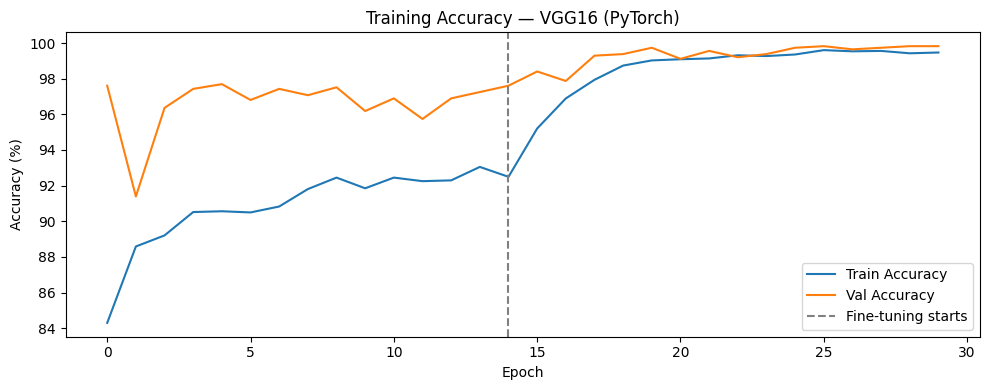

In [11]:
all_train = train_acc1 + train_acc2
all_val   = val_acc1   + val_acc2

plt.figure(figsize=(10, 4))
plt.plot([a*100 for a in all_train], label='Train Accuracy')
plt.plot([a*100 for a in all_val],   label='Val Accuracy')
plt.axvline(x=len(train_acc1) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy — VGG16 (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def evaluate_model(mdl, loader, dev='cpu'):
    mdl.eval()
    correct, total = 0, 0
    start = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(dev), labels.to(dev)
            outputs = mdl(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)
    elapsed = time.time() - start
    return 100 * correct / total, elapsed

orig_acc, orig_time = evaluate_model(model, val_loader, device)
print(f"Original Model — Accuracy: {orig_acc:.2f}%  |  Time: {orig_time:.2f}s")

Original Model — Accuracy: 99.82%  |  Time: 5.82s


In [13]:
torch.save(model.state_dict(), 'satellite_vgg16.pth')
orig_size = os.path.getsize('satellite_vgg16.pth') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 520.70 MB


In [14]:
original_model = copy.deepcopy(model).to('cpu')
original_model.eval()

quantized_model = torch.quantization.quantize_dynamic(
    original_model,
    {nn.Linear},
    dtype=torch.qint8
)

quant_size = 0
torch.save(quantized_model.state_dict(), 'satellite_vgg16_quantized.pth')
quant_size = os.path.getsize('satellite_vgg16_quantized.pth') / (1024 * 1024)

print(f"Original Model Size : {orig_size:.2f} MB")
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

/tmp/ipykernel_1646/3867846556.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Original Model Size : 520.70 MB
Quantized Model Size: 172.32 MB
Size Reduction      : 66.9%


In [16]:
def evaluate_model_fast(mdl, loader, dev='cpu', max_samples=500):
    mdl.eval()
    correct, total = 0, 0
    start = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(dev), labels.to(dev)
            outputs = mdl(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)
            if total >= max_samples:
                break
    elapsed = time.time() - start
    return 100 * correct / total, elapsed

quant_acc,     quant_time     = evaluate_model_fast(quantized_model, val_loader_cpu, dev='cpu')
orig_acc_cpu,  orig_time_cpu  = evaluate_model_fast(original_model,  val_loader_cpu, dev='cpu')

print(f"Original  — Accuracy: {orig_acc_cpu:.2f}%  |  Time: {orig_time_cpu:.2f}s")
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Accuracy: 99.80%  |  Time: 204.90s
Quantized — Accuracy: 99.80%  |  Time: 207.13s


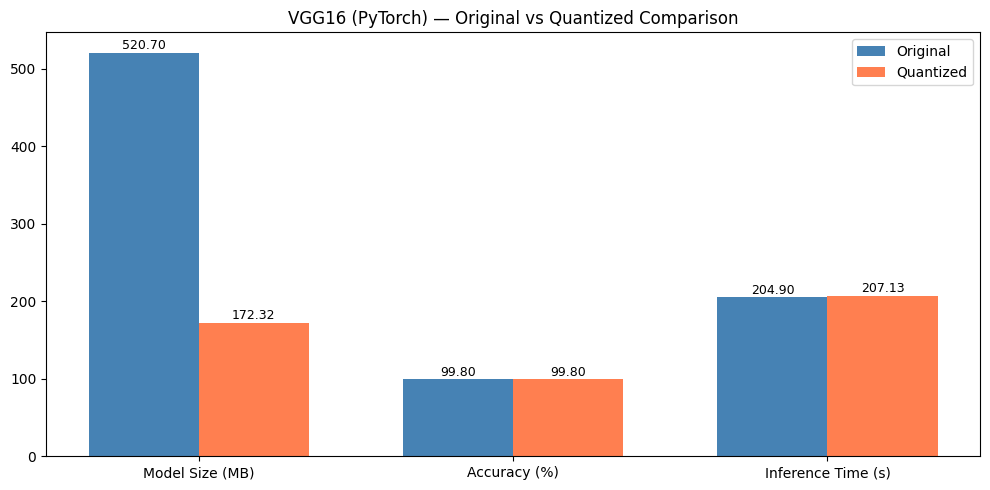

In [17]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size,  orig_acc_cpu, orig_time_cpu]
quant_vals = [quant_size, quant_acc,    quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original',  color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('VGG16 (PyTorch) — Original vs Quantized Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

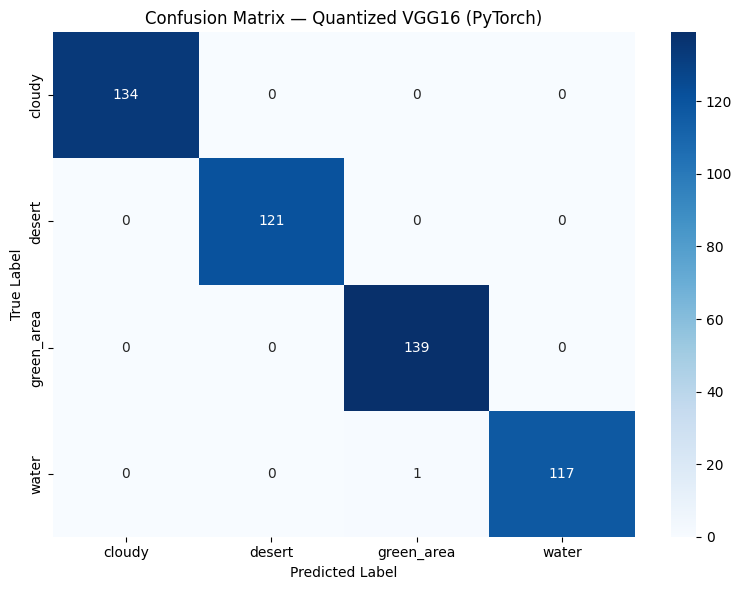

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       134
      desert       1.00      1.00      1.00       121
  green_area       0.99      1.00      1.00       139
       water       1.00      0.99      1.00       118

    accuracy                           1.00       512
   macro avg       1.00      1.00      1.00       512
weighted avg       1.00      1.00      1.00       512



In [18]:
all_preds  = []
all_labels = []
count      = 0

quantized_model.eval()
with torch.no_grad():
    for images, labels in val_loader_cpu:
        outputs = quantized_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        count += len(labels)
        if count >= 500:
            break

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized VGG16 (PyTorch)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [19]:
from google.colab import files
files.download('satellite_vgg16.pth')
files.download('satellite_vgg16_quantized.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>